In [1]:
    import meep as mp
    from meep import mpb as mpb
    import numpy as np
    import matplotlib.pyplot as plt

In [2]:
#Meep Units

# a = 1um (characteristic scale)
lambda_um = 1.55
f = 1/lambda_um #in meep units
SIN_epsilon = 1.974
SIO2_epsilon = 1.4657

waveguide_length = 50
mm_waveguide_length = 360 #305 works when the resolution is low
mm_width = 24
taper_length = 50 #this willa taper from the 1 micron wide wave guide to a 30 micron wide

waveguide_spacing = 8 
taper_mode_size = 2.5 #half

cell_x_um = mm_waveguide_length + waveguide_length + waveguide_length + taper_length + taper_length
cell_y_um = np.ceil(1.2 * mm_width)
resolution = 12 #10 pixels per wavelength

input_taper_verticies = [mp.Vector3(-cell_x_um/2 + waveguide_length, -waveguide_spacing/2 - 0.5),
                         mp.Vector3(-cell_x_um/2 + waveguide_length + taper_length, -waveguide_spacing/2 - taper_mode_size),
                         mp.Vector3(-cell_x_um/2 + waveguide_length + taper_length, -waveguide_spacing/2 + taper_mode_size),
                         mp.Vector3(-cell_x_um/2 + waveguide_length, -waveguide_spacing/2 + 0.5)]
                         
alt_input_taper_verticies = [mp.Vector3(-cell_x_um/2 + waveguide_length, waveguide_spacing/2 - 0.5),
                         mp.Vector3(-cell_x_um/2 + waveguide_length + taper_length, waveguide_spacing/2 - taper_mode_size),
                         mp.Vector3(-cell_x_um/2 + waveguide_length + taper_length, waveguide_spacing/2 + taper_mode_size),
                         mp.Vector3(-cell_x_um/2 + waveguide_length, waveguide_spacing/2 + 0.5)]

output_taper_verticies = [mp.Vector3(cell_x_um/2 - waveguide_length, -waveguide_spacing/2 - 0.5),
                         mp.Vector3(cell_x_um/2 - waveguide_length - taper_length, -waveguide_spacing/2 - taper_mode_size),
                         mp.Vector3(cell_x_um/2 - waveguide_length - taper_length, -waveguide_spacing/2 + taper_mode_size),
                         mp.Vector3(cell_x_um/2 - waveguide_length, -waveguide_spacing/2 + 0.5)]
                         
alt_output_taper_verticies = [mp.Vector3(cell_x_um/2 - waveguide_length, waveguide_spacing/2 - 0.5),
                         mp.Vector3(cell_x_um/2 - waveguide_length - taper_length, waveguide_spacing/2 - taper_mode_size),
                         mp.Vector3(cell_x_um/2 - waveguide_length - taper_length, waveguide_spacing/2 + taper_mode_size),
                         mp.Vector3(cell_x_um/2 - waveguide_length, waveguide_spacing/2 + 0.5)]


                             
input_taper = mp.Prism(input_taper_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))
alt_input_taper = mp.Prism(alt_input_taper_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))
output_taper = mp.Prism(output_taper_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))
alt_output_taper = mp.Prism(alt_output_taper_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))

input_wave_guide = mp.Block(mp.Vector3(waveguide_length ,1,mp.inf),
                     center=mp.Vector3(-cell_x_um/2 + waveguide_length/2, -waveguide_spacing/2),
                     material=mp.Medium(epsilon=SIN_epsilon))

alt_input_wave_guide = mp.Block(mp.Vector3(waveguide_length ,1,mp.inf),
                     center=mp.Vector3(-cell_x_um/2 + waveguide_length/2, waveguide_spacing/2),
                     material=mp.Medium(epsilon=SIN_epsilon))


output_waveguide = mp.Block(mp.Vector3(waveguide_length ,1,mp.inf),
                     center=mp.Vector3(cell_x_um/2 - waveguide_length/2, -waveguide_spacing/2),
                     material=mp.Medium(epsilon=SIN_epsilon))
 
alt_output_waveguide = mp.Block(mp.Vector3(waveguide_length ,1,mp.inf),
                     center=mp.Vector3(cell_x_um/2 - waveguide_length/2, waveguide_spacing/2),
                     material=mp.Medium(epsilon=SIN_epsilon))
 
multimode_waveguide  = mp.Block(mp.Vector3(mm_waveguide_length, mm_width, mp.inf),
                     center=mp.Vector3(-cell_x_um/2 + mm_waveguide_length/2 + waveguide_length+taper_length, 0, 0),
                     material=mp.Medium(epsilon=SIN_epsilon))

cell = mp.Vector3(cell_x_um,cell_y_um,0)



geometry = [output_taper, alt_output_taper, input_taper, alt_input_taper, input_wave_guide,alt_input_wave_guide,output_waveguide,alt_output_waveguide, multimode_waveguide]

sources = [
    mp.GaussianBeamSource(
        src=mp.ContinuousSource(f),
        center=mp.Vector3(-cell_x_um/2 + 1, -waveguide_spacing/2),
        size=mp.Vector3(0,5),
        beam_kdir=mp.Vector3(1,0),
        beam_w0=0.8,
        beam_E0=mp.Vector3(0,0,1),
    )
]

# sources = [mp.Source(                                   
#                                     mp.ContinuousSource(frequency=f),
#                                     size = mp.Vector3(0, 15),
#                                     component = mp.Ez,
#                                     center=mp.Vector3(-cell_x_um/2 + 1, -11))]
pml_layers = [mp.PML(1.0)]
symmetries=[]
sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution,
                    default_material=mp.Medium(epsilon=SIO2_epsilon),
                    symmetries=symmetries)
# eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)

sim.run(until=2*cell_x_um)



-----------
Initializing structure...
time for choose_chunkdivision = 0.00173402 s
Working in 2D dimensions.
Computational cell is 560 x 29 x 0 with resolution 12
     prism, center = (205,-4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (230,-4.5,0)
          (180,-6.5,0)
          (180,-1.5,0)
          (230,-3.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, center = (205,4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (230,3.5,0)
          (180,1.5,0)
          (180,6.5,0)
          (230,4.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, center = (-205,-4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-230,-4.5,0)
          (-180,-6.5,0)
          (-180,-1.5,0)
          (-230,-3.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, cen

FloatProgress(value=0.0, description='0% done ', max=1120.0)

Meep progress: 9.0/1120.0 = 0.8% done in 4.0s, 494.0s to go
on time step 217 (time=9.04167), 0.0185016 s/step
Meep progress: 18.708333333333332/1120.0 = 1.7% done in 8.0s, 471.6s to go
on time step 450 (time=18.75), 0.0172012 s/step
Meep progress: 29.291666666666664/1120.0 = 2.6% done in 12.0s, 447.7s to go
on time step 704 (time=29.3333), 0.0157937 s/step
Meep progress: 39.33333333333333/1120.0 = 3.5% done in 16.0s, 440.3s to go
on time step 945 (time=39.375), 0.0166166 s/step
Meep progress: 49.45833333333333/1120.0 = 4.4% done in 20.0s, 433.6s to go
on time step 1188 (time=49.5), 0.0164813 s/step
Meep progress: 60.916666666666664/1120.0 = 5.4% done in 24.0s, 418.0s to go
on time step 1463 (time=60.9583), 0.0145758 s/step
Meep progress: 72.125/1120.0 = 6.4% done in 28.1s, 407.6s to go
on time step 1732 (time=72.1667), 0.014933 s/step
Meep progress: 82.875/1120.0 = 7.4% done in 32.1s, 401.2s to go
on time step 1991 (time=82.9583), 0.0155 s/step
Meep progress: 94.375/1120.0 = 8.4% done 

Vector3<560.0, 29.0, 0.0>


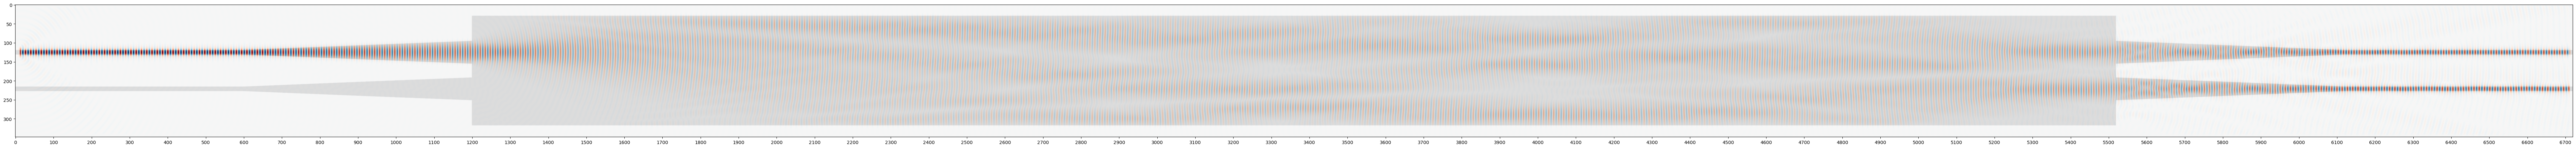

In [5]:
print(sim.cell_size)
eps_data = sim.get_array(center=mp.Vector3(), size=sim.cell_size, component=mp.Dielectric)
ez_data = sim.get_array(center=mp.Vector3(), size=sim.cell_size, component=mp.Ez)
fig = plt.figure(figsize=(100,30))
plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
# plt.figsize(10,10)
# plt.imshow(np.log(np.abs(ez_data.transpose())+1), alpha=0.9, )
plt.imshow(ez_data.transpose(), cmap="RdBu", alpha=0.9, )

# plt.axis('off')
plt.xticks((np.arange(0, sim.cell_size[0] * sim.resolution, 100)))
plt.show()

Lambda: 1550.0 nm
error paramas: -0.03125254712030168 (dB) ∠ 0.21948332525131775 deg
S31 paramas: -3.333406023807946 (dB) ∠ -154.36200387005013 deg
S41 paramas: -3.3019713880085093 (dB) ∠ -64.58129264770213 deg


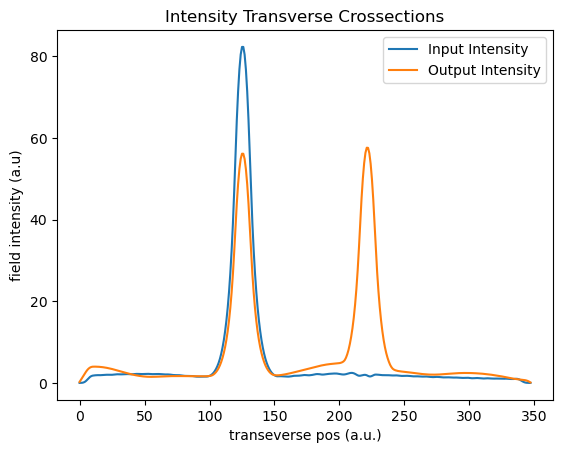

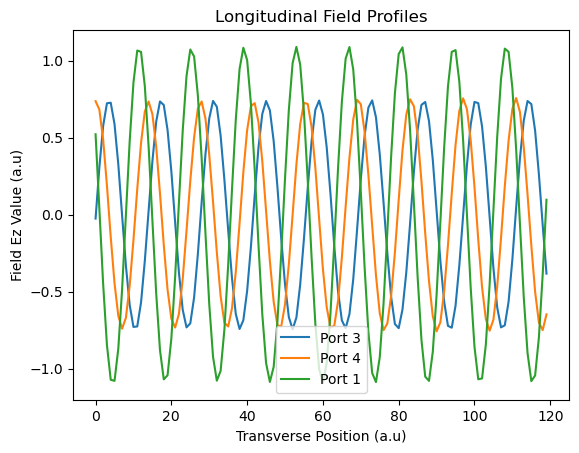

In [4]:
#Cell to get the scatttering paramters of the system

ez_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Ez)


input_field = np.sum(np.abs(ez_data[3*resolution:13*resolution, :]), axis=0)
output_field = np.sum(np.abs(ez_data[-13*resolution:-3*resolution, :]),axis=0)

plt.figure()
plt.title("Intensity Transverse Crossections")
plt.plot(np.abs(input_field), label="Input Intensity")
plt.plot(np.abs(output_field), label="Output Intensity")
plt.legend()
plt.xlabel("transeverse pos (a.u.)")
plt.ylabel("field intensity (a.u)")

out1_pos = ez_data.shape[1]//2 - waveguide_spacing//2 * resolution
out2_pos = ez_data.shape[1]//2 + waveguide_spacing//2 * resolution
input_pos = ez_data.shape[1]//2 - waveguide_spacing//2 * resolution
output1 = ez_data[-13*resolution:-3 *resolution , out1_pos]
output2 = ez_data[-13*resolution:-3*resolution, out2_pos]
input1 = ez_data[3*resolution: 13*resolution, input_pos]
plt.figure()
plt.title("Longitudinal Field Profiles")
plt.plot(output1, label="Port 3")
plt.plot(output2, label="Port 4")
plt.plot(input1, label="Port 1")
plt.legend()
plt.xlabel("Transverse Position (a.u)")
plt.ylabel("Field Ez Value (a.u)")

import scipy.signal as sp
window = np.kaiser(len(output1),6)
# window = np.ones_like(output1)
i1 = sp.hilbert(input1*window)
h1 = sp.hilbert(output1*window)
h2 = sp.hilbert(output2*window)
phase_difference = (np.degrees(np.unwrap(np.angle(h1))- np.unwrap(np.angle(h2))))
amplitude_imbalance = 20*np.log10(np.abs(h1)) - 20*np.log10(np.abs(h2))
exclude_edge = 25

phase = np.mean(phase_difference[exclude_edge:-exclude_edge])
amplitude = np.mean(amplitude_imbalance[exclude_edge:-exclude_edge])
print("Lambda:",lambda_um*1000, "nm")
print("error paramas:", amplitude, "(dB) ∠", phase + 90, "deg") 

#scattering params

S31 = h1/i1
S31 = np.mean(S31[exclude_edge:-exclude_edge])
S41 = h2/i1
S41 = np.mean(S41[exclude_edge:-exclude_edge])

print("S31 paramas:", 20*np.log10(np.abs(S31)), "(dB) ∠", np.degrees(np.angle(S31)), "deg") 
print("S41 paramas:", 20*np.log10(np.abs(S41)), "(dB) ∠", np.degrees(np.angle(S41)), "deg") 




In [ ]:

n_core = SIN_epsilon # Silicon
n_clad = SIO2_epsilon # SiO2
core = mp.Medium(index=n_core)
cladding = mp.Medium(index=n_clad)
print(n_core, n_clad)
mp.verbosity(1)
resolution = 5 # pixels/μm

geometry_lattice = mp.Lattice(size=mp.Vector3(30,2))

w = 24  # width of waveguide
h = 0.8 # height of waveguide

geometry = [
    mp.Block(center=mp.Vector3(), size=mp.Vector3(mp.inf, mp.inf), material=cladding),
    mp.Prism(vertices = [mp.Vector3(-w/2,-h/2),mp.Vector3(w/2,-h/2),mp.Vector3(w/2,h/2), mp.Vector3(-w/2,h/2)],
        height = 0.1,
        axis = mp.Vector3(0,0,1),
        material=core)
           ]

wl0 = 1.55
freq = 1./wl0
num_modes = 20 
ms = mpb.ModeSolver(
    geometry_lattice=geometry_lattice,
    geometry=geometry,
    resolution=resolution,
    num_bands=num_modes,
)

ms.init_params(mp.NO_PARITY, True)

eps = ms.get_epsilon()
x = np.arange(eps.shape[0]) / resolution
y = np.arange(eps.shape[1]) / resolution
plt.figure()
plt.contourf(x,y,eps.transpose(), cmap = 'binary')
plt.colorbar(label = "Permittivity")
# plt.savefig("Eps.png")
# plt.close()


tol = 1e-5

n_mode_guess = 0.5 * (n_core + n_clad)
n_mode_min = n_clad
n_mode_max = n_core


k_guess = freq * n_mode_guess
k_min = freq * n_mode_min
k_max = freq * n_mode_max

neff = []
cmap = 'seismic'
Saved_Electric_Fields = []
saved_total_fields = []
for mode_num in range(1, num_modes + 1):
    k_mpb = ms.find_k(mp.NO_PARITY, freq, mode_num, mode_num, mp.Vector3(0,0,1), tol, k_guess, k_min, k_max)
    
    neff.append(k_mpb[0]/freq)
    E = ms.get_efield(which_band=mode_num)
    H = ms.get_hfield(which_band=mode_num)
    P = ms.get_poynting(which_band=mode_num)

    Ex = E[:,:,0,0]
    Ey = E[:,:,0,1]
    Ez = E[:,:,0,2]

    Pz = 0.5 * np.real(P[:,:,0,2])
    plt.figure()
    plt.subplot(121)
    plt.contourf(x,y,np.abs(Ex.transpose()),202,cmap = cmap)
    Saved_Electric_Fields.append(Ex.transpose()[0, :])
    saved_total_fields.append(Ex.transpose())
    # plt.colorbar()
    # plt.xlabel("x"); plt.ylabel("y")
    plt.subplot(122)
    plt.contourf(x,y,Pz.transpose(),202,cmap = cmap)
    # plt.colorbar()
    # plt.xlabel("x"); plt.ylabel("y")
    # plt.savefig(f"Poynting_{mode_num}.png")
    # plt.close()

print(neff)


In [ ]:
def fit_k(x, y):
    """
    Fit y = k * x*(x+2)/3

    Parameters
    ----------
    x : array-like
        x data
    y : array-like
        y data

    Returns
    -------
    k : float
        Best-fit parameter
    """
    x = np.asarray(x)
    y = np.asarray(y)

    g = x * (x + 2) / 3.0 * np.pi
    k = np.dot(g, y) / np.dot(g, g)

    return k
beta = (np.array(neff[0:11]) * 2 * np.pi)/wl0
print("Effective Indexes", neff)
beta =  beta[0] - beta 
print("Phase Velocitites", beta)
# unique_phase_constants = np.unique(np.round(beta, 3))
x = np.arange(1, len(beta)+1, 1)
plt.scatter(x, beta)
k = fit_k(x, beta)
plt.plot(x, np.pi*k*x*(x+2)/3)
Lpi = np.pi / beta[1]
print("Critical Length um", Lpi)
print("Fitted Critical Length", 1/k)

print("Critical Phase", beta*1/k*6 /(2*np.pi))




In [ ]:
def GetPropogatedField(mode_profiles, overlaps, delta_phase_velocities, propgation_length):
    phases = delta_phase_velocities * propgation_length   
    total_field = np.sum([overlaps[i]*mode_profiles[i]*np.exp(1j*phases[i]) for i in range(len(mode_profiles))], axis=0)
    return total_field  

def Get_Overlap(input_field, mode):
    """function that finds the overlap of the input field with a given mode"""
    return (np.sum(np.conj(input_field)*mode))**2 / np.sum(np.abs(mode))

mode_cutoff = 11
delta_phase_velocities = (np.array(neff[:mode_cutoff]) * 2 * np.pi)/wl0
delta_phase_velocities = np.array(delta_phase_velocities[0] - delta_phase_velocities)
mode_profiles = Saved_Electric_Fields[:mode_cutoff]
x = np.arange(eps.shape[0]) / resolution

plt.figure()
for mode in mode_profiles:
    plt.plot(x, np.real(mode))

input_mode = np.exp(-(x - x[len(x)//2 + 20])**2/5) * np.max(np.real(mode_profiles[0]))
input_mode = np.sum([1/(2*k + 1) * mode_profiles[2*k] for k in range(3)], axis=0)
input_mode = np.zeros_like(mode_profiles[0])
input_mode[15*5 + 24//6 * 5: 15*5 + 24//6 * 5 + 8*5] = 0.02

plt.plot(x, np.real(input_mode), label="input field")
overlaps = []
for i in range(len(mode_profiles)):
    overlaps.append(Get_Overlap(input_mode, mode_profiles[i]))

# cutoff = 0.00001
# for i, overlap in enumerate(overlaps):
#     # print(i, np.abs(overlap))
#     if np.abs(overlap) < cutoff:
#         overlaps[i] = 0

print("Overlaps", np.round(overlaps,20))
overlaps = overlaps / np.linalg.norm(overlaps)

reconstructed_field = np.sum(np.array([overlaps[i]*mode_profiles[i] for i in range(len(mode_profiles))]),axis=0)
# print(reconstructed_field.shape)
# autre_field = overlaps[3]*mode_profiles[3] + overlaps[5]*mode_profiles[5]

# plt.plot(x, np.real(reconstructed_field), label="approx_field")
plt.legend()
plt.figure()
plt.plot(x, np.real(reconstructed_field), label="reconstructed field")
plt.plot(x, np.real(input_mode), label="true field")
# plt.plot(x, np.real(autre_field), label="rounded")
plt.legend()
propgation_lengths = np.linspace(0, 4000, 5000)
total_fields = np.array([GetPropogatedField(mode_profiles, overlaps, delta_phase_velocities, propgation_lengths[i]) for i in range(len(propgation_lengths))])
print(total_fields.shape)
plt.figure()
plt.imshow(np.abs(total_fields.T), aspect = "auto")
plt.show()



In [ ]:
matrix_size = 11
basis_matrix = np.zeros((matrix_size,matrix_size), dtype=complex)
def Get_Overlap(input_field, mode):
    """function that finds the overlap of the input field with a given mode"""
    return (np.sum(np.conj(input_field)*mode))**2 /np.sum(mode * np.conj(mode)) /np.sum(input_field *np.conj(input_field))
for i, mode1 in enumerate(mode_profiles):
    for j, mode2 in enumerate(mode_profiles):

        basis_matrix[i,j] = Get_Overlap(mode1, mode2)

print(np.round(np.abs(basis_matrix), 3))
        

In [ ]:
def get_eigencoefficent(field , eigenmode):
    """function that finds the overlap of the input field with a given mode"""
    return (np.sum(np.conj(field)*eigenmode)) /np.sum(np.abs(eigenmode)**2)


mode_cutoff = 11
delta_phase_velocities = (np.array(neff[:mode_cutoff]) * 2 * np.pi)/wl0
delta_phase_velocities = np.array(delta_phase_velocities[0] - delta_phase_velocities)
mode_profiles = saved_total_fields[:mode_cutoff]
x = np.arange(eps.shape[0]) / resolution
y = np.arange(eps.shape[1]) / resolution

ux, uy = np.meshgrid(x, y)
wx = 30
wy = 0.2
input_mode = np.exp(1j)*np.exp((-(ux-40)**2/wx)) * np.exp(-(uy-1)**2/wy)

input_mode = np.zeros_like(mode_profiles[0])
print(input_mode.shape)
input_mode[2:7, 75:150] = 1


# input_mode = mode_profiles[3] + mode_profiles[5]
plt.figure()
plt.contourf(x,y,np.abs(mode_profiles[10]),202,cmap = cmap)
plt.figure()
plt.contourf(x,y,np.abs(input_mode),202,cmap = cmap)

overlaps = []
for i in range(len(mode_profiles)):
    overlaps.append(get_eigencoefficent(input_mode, mode_profiles[i]))
    # print(i, overlaps[i])
overlaps = overlaps / np.linalg.norm(overlaps)
for i in range(len(mode_profiles)):
    print(i, np.round(overlaps[i],2))# print(overlaps)
reconstructed_field = np.sum(np.array([overlaps[i]*mode_profiles[i] for i in range(len(mode_profiles))]),axis=0)
plt.figure()
plt.contourf(x,y,np.abs(reconstructed_field),202,cmap = cmap)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000767946 s
Working in 2D dimensions.
Computational cell is 560 x 29 x 0 with resolution 4
     prism, center = (-205,4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-230,3.5,0)
          (-180,1.5,0)
          (-180,6.5,0)
          (-230,4.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, center = (-205,-4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (-230,-4.5,0)
          (-180,-6.5,0)
          (-180,-1.5,0)
          (-230,-3.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, center = (205,4,5e+19)
          height 1e+20, axis (0,0,1), sidewall angle: 0 radians, 4 vertices:
          (230,3.5,0)
          (180,1.5,0)
          (180,6.5,0)
          (230,4.5,0)
          dielectric constant epsilon diagonal = (1.974,1.974,1.974)
     prism, cen

FloatProgress(value=0.0, description='0% done ', max=1.0)

run 0 finished at t = 1.0 (8 timesteps)


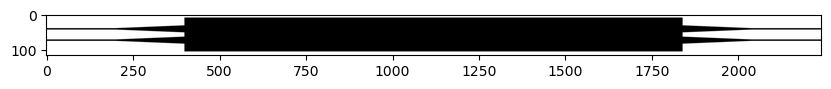

In [11]:
import meep as mp
import numpy as np
import matplotlib.pyplot as plt


#CONSTANTS
    #a note on units c=1 and a=1um so all meep units are in microns (including time)
SIN_epsilon = 1.974
SIO2_epsilon = 1.4657



def GenerateTaperGeometry(taper_length, taper_input_width, taper_output_width, start_position_x, start_position_y, direction):
    if direction == 'right':
        taper_verticies = [mp.Vector3(start_position_x, start_position_y - taper_input_width/2),
                                    mp.Vector3(start_position_x + taper_length, start_position_y - taper_output_width/2),
                                    mp.Vector3(start_position_x + taper_length, start_position_y + taper_output_width/2),
                                    mp.Vector3(start_position_x, start_position_y + taper_input_width/2)]
    elif direction == 'left':
        taper_verticies = [mp.Vector3(start_position_x, start_position_y - taper_input_width/2),
                                    mp.Vector3(start_position_x - taper_length, start_position_y - taper_output_width/2),
                                    mp.Vector3(start_position_x - taper_length, start_position_y + taper_output_width/2),
                                    mp.Vector3(start_position_x, start_position_y + taper_input_width/2)]
    else:
        raise ValueError("Direction must be 'right' or 'left'")
    taper = mp.Prism(taper_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))
    return taper

def GenerateWaveguideGeometry(waveguide_length, waveguide_width, start_position_x, start_position_y):
    waveguide_verticies = [mp.Vector3(start_position_x, start_position_y - 0.5*waveguide_width),
                                         mp.Vector3(start_position_x + waveguide_length, start_position_y - 0.5*waveguide_width),
                                         mp.Vector3(start_position_x + waveguide_length, start_position_y + 0.5*waveguide_width),
                                         mp.Vector3(start_position_x, start_position_y + 0.5*waveguide_width)]
    waveguide = mp.Prism(waveguide_verticies,height=mp.inf,material=mp.Medium(epsilon=SIN_epsilon))
    return waveguide

def GenerateMMIGeometry(   sm_waveguide_length, sm_waveguide_width,
                                                sm_waveguide_spacing,
                                                mm_waveguide_length, mm_waveguide_width, 
                                                taper_length, taper_output_width):
    """Generates the geometry for a 2x2 MMI coupler with the specified parameters."""
    cell_x_um = mm_waveguide_length + 2*sm_waveguide_length + 2*taper_length
    cell_y_um = np.ceil(1.2 * mm_waveguide_width)

    P1_taper = GenerateTaperGeometry(taper_length, sm_waveguide_width, taper_output_width, -cell_x_um/2 + sm_waveguide_length, sm_waveguide_spacing/2, 'right')
    P2_taper = GenerateTaperGeometry(taper_length, sm_waveguide_width, taper_output_width, -cell_x_um/2 + sm_waveguide_length, -sm_waveguide_spacing/2, 'right')
    P3_taper = GenerateTaperGeometry(taper_length, sm_waveguide_width, taper_output_width, cell_x_um/2 - sm_waveguide_length, sm_waveguide_spacing/2, 'left')
    P4_taper = GenerateTaperGeometry(taper_length, sm_waveguide_width, taper_output_width, cell_x_um/2 - sm_waveguide_length, -sm_waveguide_spacing/2, 'left')

    P1_waveguide = GenerateWaveguideGeometry(sm_waveguide_length, sm_waveguide_width, -cell_x_um/2, sm_waveguide_spacing/2)
    P2_waveguide = GenerateWaveguideGeometry(sm_waveguide_length, sm_waveguide_width, -cell_x_um/2, -sm_waveguide_spacing/2)
    P3_waveguide = GenerateWaveguideGeometry(sm_waveguide_length, sm_waveguide_width, cell_x_um/2 - sm_waveguide_length, sm_waveguide_spacing/2)
    P4_waveguide = GenerateWaveguideGeometry(sm_waveguide_length, sm_waveguide_width, cell_x_um/2 - sm_waveguide_length, -sm_waveguide_spacing/2)
    
    mm_waveguide = GenerateWaveguideGeometry(mm_waveguide_length, mm_waveguide_width, -cell_x_um/2 + sm_waveguide_length + taper_length, 0)
    cell = mp.Vector3(cell_x_um,cell_y_um,0)
    geometry = [P1_taper, P2_taper, P3_taper, P4_taper, P1_waveguide, P2_waveguide, P3_waveguide, P4_waveguide, mm_waveguide]
    # geometry = [P1_waveguide, P2_waveguide, P3_waveguide, P4_waveguide, mm_waveguide]

    return geometry, cell

geometry, cell = GenerateMMIGeometry(   sm_waveguide_length=50,
                                                sm_waveguide_width=1,
                                                sm_waveguide_spacing=8,
                                                mm_waveguide_length=360,
                                                mm_waveguide_width=24,
                                                taper_length=50,
                                                taper_output_width=5)

sources = []
pml_layers = [mp.PML(1.0)]
symmetries=[]
resolution = 4
sim = mp.Simulation(cell_size=cell,
                    boundary_layers=pml_layers,
                    geometry=geometry,
                    sources=sources,
                    resolution=resolution,
                    default_material=mp.Medium(epsilon=SIO2_epsilon),
                    symmetries=symmetries)

sim.run(until=1)
eps_data = sim.get_array(center=mp.Vector3(), size=cell, component=mp.Dielectric)
fig = plt.figure(figsize=(10,3))
plt.imshow(eps_data.transpose(), interpolation='spline36', cmap='binary')
# plt.savefig('MMI_Geometry.png', dpi=300)